In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from windrose import WindroseAxes
import seaborn as sns


df_on = pd.read_csv("data/Onshore_official_data_incl_prices.csv")
df_off = pd.read_csv("data/Offshore_official_data_incl_prices.csv")


In [26]:
print("Onshore DataFrame info:\n")
df_on.info()
print("\nOffshore DataFrame info:\n")
df_off.info()

print("\nOnshore data sample:\n", df_on.head())
print("\nOffshore data sample:\n", df_off.head())

# Basic descriptive statistics
print("\nOnshore numeric stats:")
display(df_on.describe())

print("\nOffshore numeric stats:")
display(df_off.describe())


Onshore DataFrame info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70128 entries, 0 to 70127
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              70128 non-null  object 
 1   year_mon_day            70128 non-null  int64  
 2   hour                    70128 non-null  int64  
 3   wind_dir_avg_10         70128 non-null  float64
 4   wind_speed_h_avg        70128 non-null  float64
 5   wind_speed_avg_10       70128 non-null  float64
 6   air_pressure            70128 non-null  float64
 7   humidity                70128 non-null  float64
 8   full_datetime           70128 non-null  object 
 9   capacity                70128 non-null  int64  
 10  volume                  70128 non-null  int64  
 11  percentage              70128 non-null  float64
 12  emission                70128 non-null  int64  
 13  emissionfactor          70128 non-null  int64  
 14  correct_days 

,year_mon_day,hour,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,capacity,volume,percentage,emission,emissionfactor,week_number,max_capacity,log_volume,ratio_VC,prijs_excl_belastingen
count,7.012800e+04,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,7.012800e+04,7.012800e+04,70128.000000,70128.0,70128.0,70128.000000,6.851900e+04,70128.000000,68519.000000,70120.000000
mean,2.020568e+07,11.500000,188.994414,41.623180,41.760203,10153.336506,79.878742,9.102452e+05,9.102452e+05,0.548926,0.0,0.0,209.214579,1.600871e+06,12.812230,0.561816,0.085313
std,2.291693e+04,6.922236,93.080745,20.794357,20.832630,103.807465,14.362530,9.476941e+05,9.476941e+05,0.439403,0.0,0.0,120.502271,6.516011e+05,2.369857,0.436311,0.087668
min,2.017010e+07,0.000000,0.004785,5.000000,5.333333,9696.350000,20.592593,0.000000e+00,0.000000e+00,0.000000,0.0,0.0,1.000000,8.598425e+05,0.000000,0.000035,-0.500000
25%,2.019010e+07,5.750000,115.866256,26.129032,26.333333,10092.300000,71.887821,2.246188e+05,2.246188e+05,0.165012,0.0,0.0,105.000000,8.613001e+05,12.322164,0.181832,0.036500
50%,2.020567e+07,11.500000,205.663930,37.931034,38.000000,10160.650000,83.846154,6.090395e+05,6.090395e+05,0.468765,0.0,0.0,209.000000,2.196447e+06,13.319640,0.486377,0.054000
75%,2.023010e+07,17.250000,253.231014,53.225806,53.333333,10222.700000,91.074074,1.196671e+06,1.196671e+06,0.877715,0.0,0.0,314.000000,2.196450e+06,13.995055,0.886381,0.100000
max,2.024123e+07,23.000000,360.000000,183.666667,185.000000,10481.400000,99.115385,4.229976e+06,4.229976e+06,1.925820,0.0,0.0,418.000000,2.196461e+06,15.257707,1.925820,0.872960



Offshore numeric stats:


,year_mon_day,hour,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,capacity,volume,percentage,emission,emissionfactor,week_number,max_capacity,log_volume,ratio_VC,prijs_excl_belastingen
count,7.012800e+04,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,7.012800e+04,7.012800e+04,70128.000000,70128.0,70128.0,70128.000000,6.966500e+04,70128.000000,69665.000000,70128.000000
mean,2.020568e+07,11.500000,191.081677,66.240729,66.328325,10146.908862,81.232306,8.264173e+05,8.264173e+05,0.481084,0.0,0.0,209.214579,1.737076e+06,12.878766,0.484282,0.085311
std,2.291693e+04,6.922236,95.851780,28.699399,28.761344,108.674679,11.101226,8.432270e+05,8.432270e+05,0.375872,0.0,0.0,120.502271,9.173146e+05,1.781875,0.375060,0.087665
min,2.017010e+07,0.000000,0.018406,9.230769,9.285714,9666.000000,26.428571,0.000000e+00,0.000000e+00,0.000000,0.0,0.0,1.000000,8.604651e+05,0.000000,0.000060,-0.500000
25%,2.019010e+07,5.750000,112.837893,44.285714,44.666667,10081.750000,74.142857,2.095000e+05,2.095000e+05,0.143837,0.0,0.0,105.000000,8.613001e+05,12.252484,0.147708,0.036500
50%,2.020567e+07,11.500000,207.327119,62.000000,62.000000,10155.750000,82.857143,5.775005e+05,5.775005e+05,0.412281,0.0,0.0,209.000000,2.196449e+06,13.266466,0.416781,0.053980
75%,2.023010e+07,17.250000,259.277968,83.333333,83.333333,10220.750000,90.142857,1.068249e+06,1.068249e+06,0.790084,0.0,0.0,314.000000,2.196900e+06,13.881532,0.792870,0.100000
max,2.024123e+07,23.000000,360.000000,227.333333,228.000000,10469.500000,99.571429,4.342999e+06,4.342999e+06,1.977283,0.0,0.0,418.000000,4.158014e+06,15.284076,1.977283,0.872960


In [27]:
print("\nNumber of missing values (onshore):\n", df_on.isnull().sum())
print("\nNumber of missing values (offshore):\n", df_off.isnull().sum())


Number of missing values (onshore):
 Unnamed: 0                   0
year_mon_day                 0
hour                         0
wind_dir_avg_10              0
wind_speed_h_avg             0
wind_speed_avg_10            0
air_pressure                 0
humidity                     0
full_datetime                0
capacity                     0
volume                       0
percentage                   0
emission                     0
emissionfactor               0
correct_days                 0
date                         0
month                        0
week_number                  0
max_capacity              1609
log_volume                   0
ratio_VC                  1609
prijs_excl_belastingen       8
dtype: int64

Number of missing values (offshore):
 Unnamed: 0                  0
year_mon_day                0
hour                        0
wind_dir_avg_10             0
wind_speed_h_avg            0
wind_speed_avg_10           0
air_pressure                0
humidity          

In [28]:
df_on['full_datetime'] = pd.to_datetime(df_on['full_datetime'], errors='coerce')
df_off['full_datetime'] = pd.to_datetime(df_off['full_datetime'], errors='coerce')

# Summary Plots and Basic Visualizations

## A. Time-Series Plots

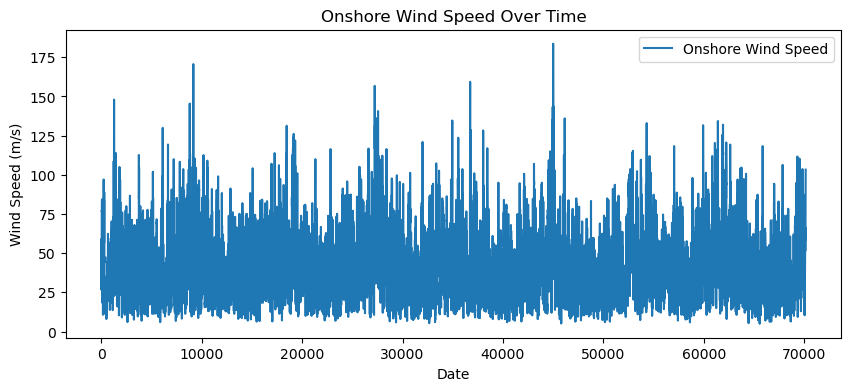

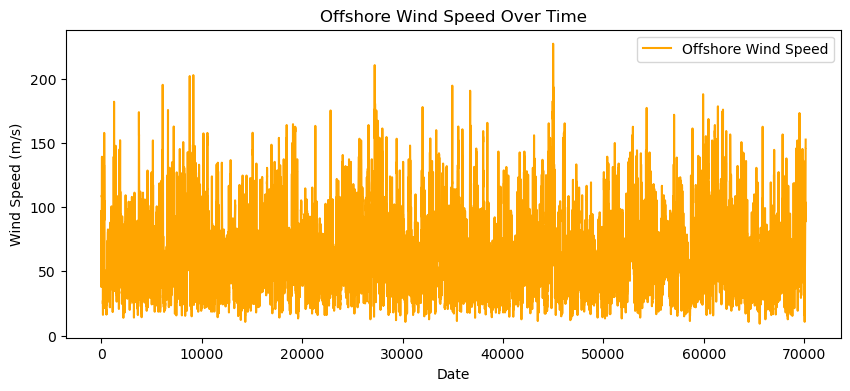

In [29]:
plt.figure(figsize=(10, 4))
plt.plot(df_on.index, df_on['wind_speed_h_avg'], label='Onshore Wind Speed')
plt.xlabel('Date')
plt.ylabel('Wind Speed (m/s)')
plt.title('Onshore Wind Speed Over Time')
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(df_off.index, df_off['wind_speed_h_avg'], color='orange', label='Offshore Wind Speed')
plt.xlabel('Date')
plt.ylabel('Wind Speed (m/s)')
plt.title('Offshore Wind Speed Over Time')
plt.legend()
plt.show()


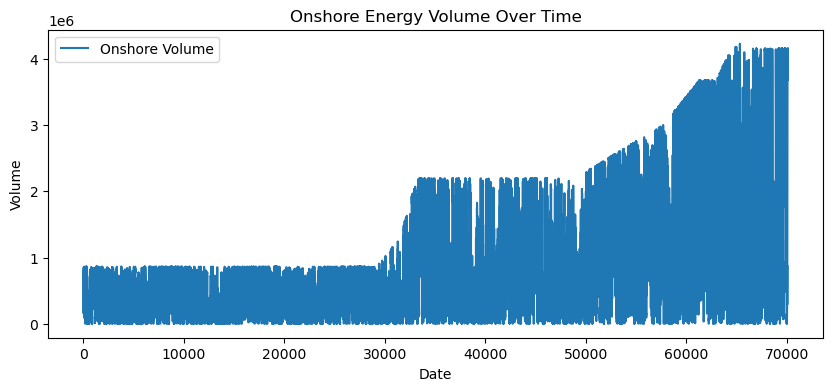

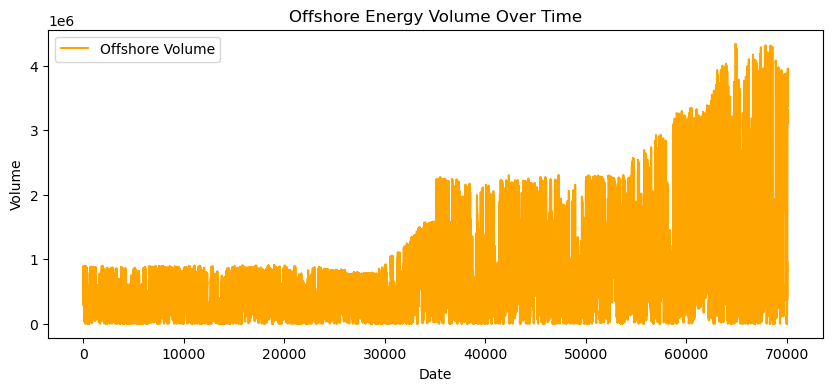

In [30]:
plt.figure(figsize=(10, 4))
plt.plot(df_on.index, df_on['volume'], label='Onshore Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.title('Onshore Energy Volume Over Time')
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(df_off.index, df_off['volume'], color='orange', label='Offshore Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.title('Offshore Energy Volume Over Time')
plt.legend()
plt.show()


## B. Histograms

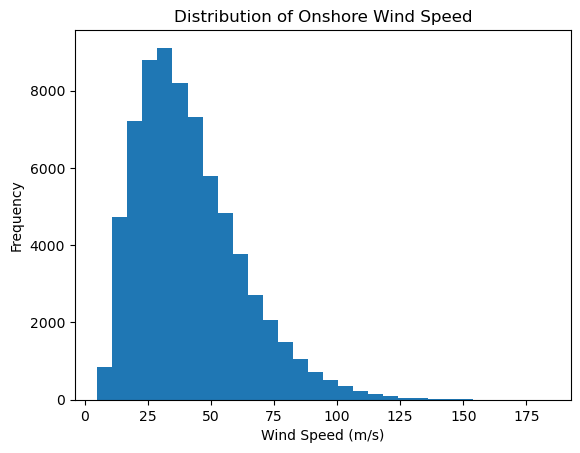

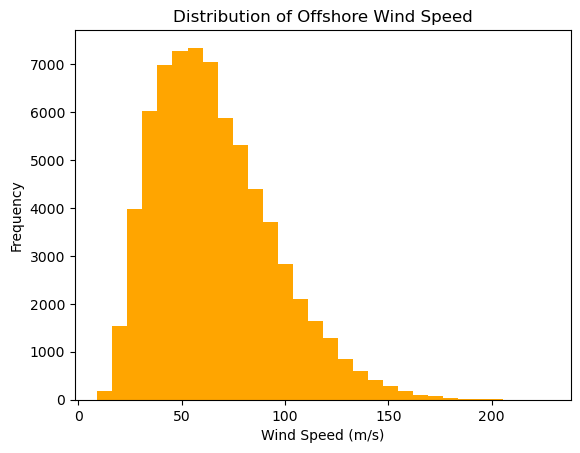

In [31]:
plt.hist(df_on['wind_speed_h_avg'].dropna(), bins=30)
plt.title('Distribution of Onshore Wind Speed')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Frequency')
plt.show()

plt.hist(df_off['wind_speed_h_avg'].dropna(), bins=30, color='orange')
plt.title('Distribution of Offshore Wind Speed')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Frequency')
plt.show()


## C. Boxplots

/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_71106/3675200272.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_on['wind_speed_h_avg'].dropna(), df_off['wind_speed_h_avg'].dropna()],


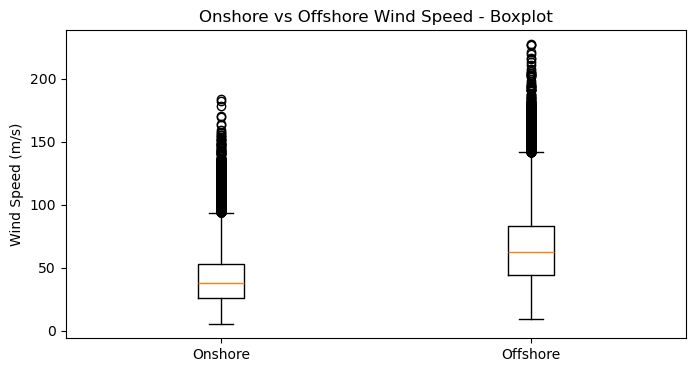

In [32]:
plt.figure(figsize=(8,4))
plt.boxplot([df_on['wind_speed_h_avg'].dropna(), df_off['wind_speed_h_avg'].dropna()],
            labels=['Onshore','Offshore'])
plt.ylabel('Wind Speed (m/s)')
plt.title('Onshore vs Offshore Wind Speed - Boxplot')
plt.show()


## D. Scatter Plots

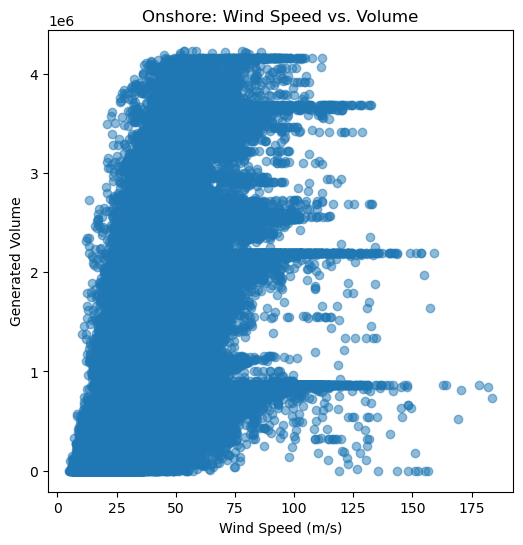

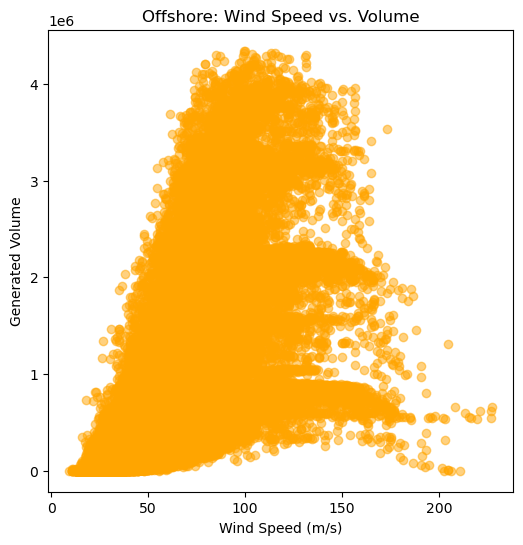

In [33]:
plt.figure(figsize=(6,6))
plt.scatter(df_on['wind_speed_h_avg'], df_on['volume'], alpha=0.5)
plt.title('Onshore: Wind Speed vs. Volume')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Generated Volume')
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(df_off['wind_speed_h_avg'], df_off['volume'], alpha=0.5, color='orange')
plt.title('Offshore: Wind Speed vs. Volume')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Generated Volume') 
plt.show()

## E. Correlation Analysis

In [34]:
corr_on = df_on[['wind_speed_h_avg', 'wind_dir_avg_10', 'air_pressure',
                 'humidity', 'volume']].corr()
print("Onshore correlation matrix:\n", corr_on)

corr_off = df_off[['wind_speed_h_avg', 'wind_dir_avg_10', 'air_pressure',
                 'humidity', 'volume']].corr()
print("Offshore correlation matrix:\n", corr_off)


Onshore correlation matrix:
                   wind_speed_h_avg  wind_dir_avg_10  air_pressure  humidity  \
wind_speed_h_avg          1.000000         0.156484     -0.373812 -0.204984   
wind_dir_avg_10           0.156484         1.000000     -0.078861  0.093625   
air_pressure             -0.373812        -0.078861      1.000000 -0.107314   
humidity                 -0.204984         0.093625     -0.107314  1.000000   
volume                    0.522428         0.087108     -0.255663  0.051945   

                    volume  
wind_speed_h_avg  0.522428  
wind_dir_avg_10   0.087108  
air_pressure     -0.255663  
humidity          0.051945  
volume            1.000000  
Offshore correlation matrix:
                   wind_speed_h_avg  wind_dir_avg_10  air_pressure  humidity  \
wind_speed_h_avg          1.000000         0.167342     -0.404357 -0.067627   
wind_dir_avg_10           0.167342         1.000000     -0.121577  0.041439   
air_pressure             -0.404357        -0.121577    

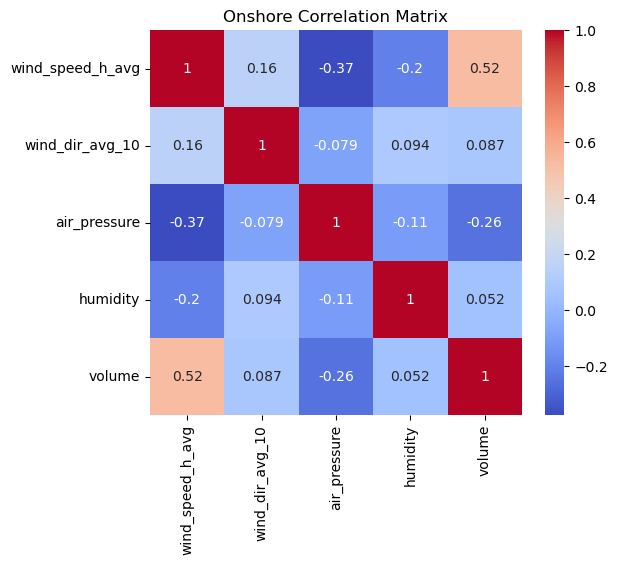

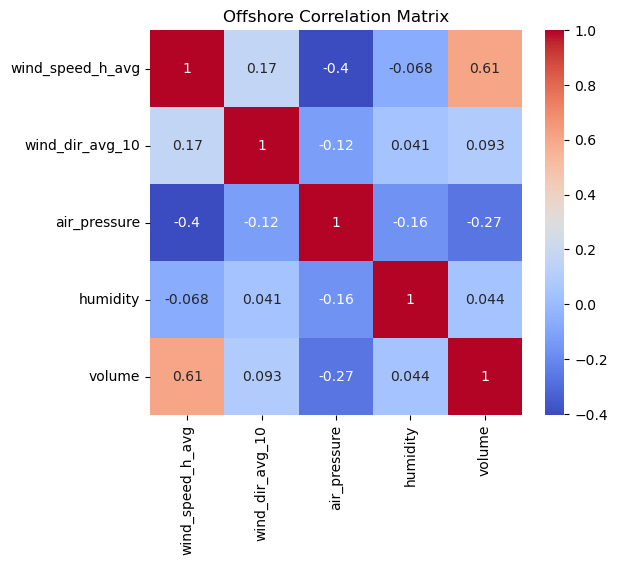

In [35]:
plt.figure(figsize=(6,5))
sns.heatmap(corr_on, annot=True, cmap='coolwarm')
plt.title('Onshore Correlation Matrix')
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(corr_off, annot=True, cmap='coolwarm')
plt.title('Offshore Correlation Matrix')
plt.show()


## F. Polar or Windrose Plots

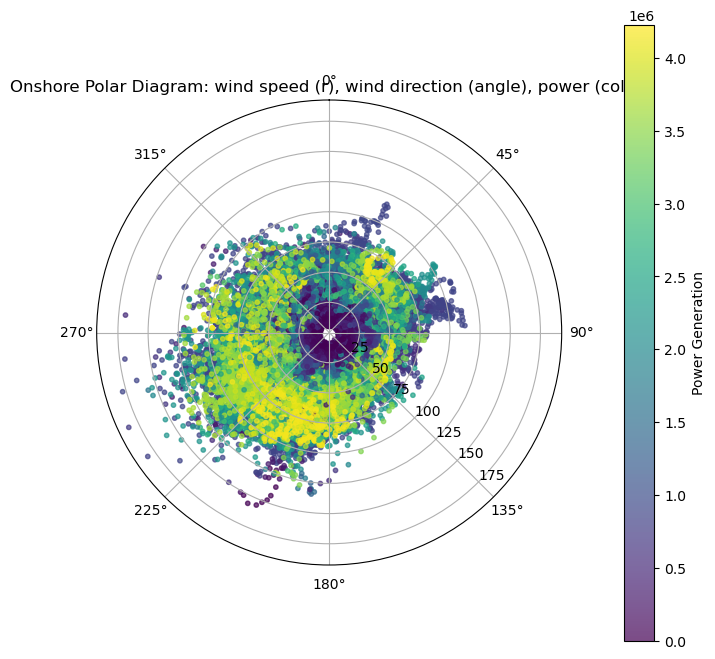

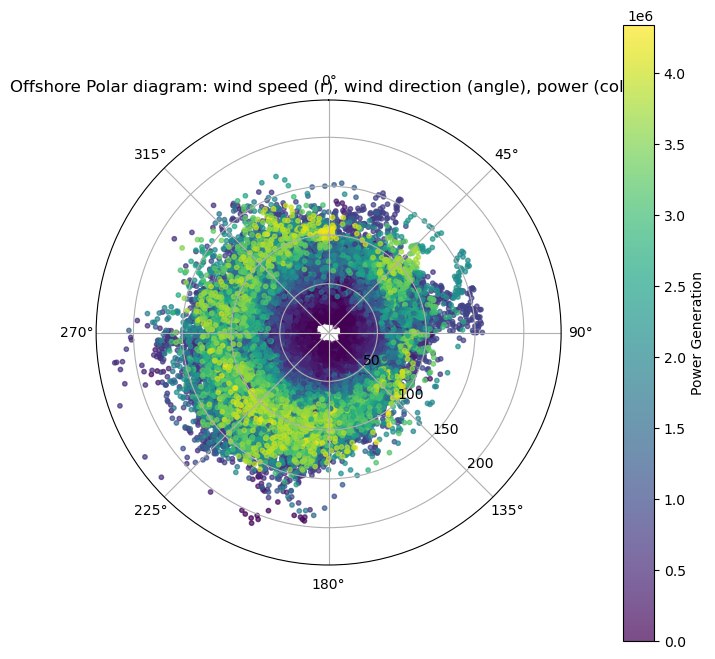

In [36]:
direction_col = 'wind_dir_avg_10'
speed_col     = 'wind_speed_h_avg'
power_col     = 'volume' 

# Convert wind direction from degrees to radians
theta_on = np.deg2rad(df_on[direction_col].values)

# Radius = wind speed
r_on = df_on[speed_col].values

# Color = power generation
c_on = df_on[power_col].values

plt.figure(figsize=(8,8))
ax_on = plt.subplot(111, projection='polar')

sc_on = ax_on.scatter(
    theta_on,          # angle
    r_on,              # radius
    c=c_on,            # point color representing power generation
    s=10,              # marker size (adjust if needed)
    cmap='viridis',    # color palette (viridis, plasma, jet, etc.)
    alpha=0.7          # transparency
)

# Color legend
cbar_on = plt.colorbar(sc_on, pad=0.1)
cbar_on.set_label("Power Generation")

# Set 0° at the top and clockwise angle counting
ax_on.set_theta_zero_location('N')
ax_on.set_theta_direction(-1)

# Adjust radius labels to avoid overlapping
ax_on.set_rlabel_position(135)

plt.title("Onshore Polar Diagram: wind speed (r), wind direction (angle), power (color)")
plt.show()

direction_col = 'wind_dir_avg_10'
speed_col     = 'wind_speed_h_avg'
power_col     = 'volume'   

# Angle in radians: wind_dir_avg_10 usually ranges from [0..360]
theta = np.deg2rad(df_off[direction_col].values)

# Radius = wind speed:
r = df_off[speed_col].values

# Color = power (or another indicator)
c = df_off[power_col].values

plt.figure(figsize=(8,8))
ax = plt.subplot(111, projection='polar')

# Create a scatter plot on a polar projection
sc = ax.scatter(
    theta,          # angle (theta)
    r,              # radius (speed)
    c=c,            # color coding based on power
    s=10,           # marker size (adjust as needed)
    cmap='viridis', # color palette
    alpha=0.7       # transparency
)

# Add a color bar as a legend
cbar = plt.colorbar(sc, pad=0.1)
cbar.set_label("Power Generation")

# Set "north" upwards (0° = N) and angle counting clockwise
ax.set_theta_zero_location('N') 
ax.set_theta_direction(-1)

# Adjust radius labels to avoid overlapping with the plot
ax.set_rlabel_position(135) 

plt.title("Offshore Polar diagram: wind speed (r), wind direction (angle), power (color)")
plt.show()


If the *onshore* polar plot shows more "yellow" points, this may indicate that the dataset more frequently contains combinations of wind speed and direction that result in power levels at the upper end of the scale (closer to 3–4 × 10^6). That is, *onshore* turbines, according to the data, often reach high levels of power generation.

### Onshore Polar Scatter
- **Many yellow points** indicate areas of high power values.  
- Specifically, at various angles (180°–250° and other sectors), if the speed (radius) is high, the power reaches 3–4 × 10^6.  

### Offshore Polar Scatter
- The colors are more frequently "green," which suggests either more consistent speeds.
- The diagram shows that even at different directions (not only within one sector), high speeds and high power are achieved.


**Interpretation**  
- The diagrams allow us to see which angles and wind speeds result in the highest power generation.  
- Strong winds come from various directions, and the color scale shows that the further from the center (higher speed), the higher the power.  
- If there is no specific "main" direction, points are relatively evenly distributed around the circle, and the primary driver of power generation is wind speed.

## Key Conclusions
1. **Offshore** has higher mean wind speeds (66 vs. 41 m/s) and a stronger link to power output (r ~ 0.61 vs. 0.52 onshore).
2. **Wind speed distribution:** broader and higher offshore, meaning more powerful and volatile conditions.
3. **Polar scatter plots** confirm that higher speeds (farther radius) yield higher power (brighter colors), regardless of wind direction.
4. **Wind direction** has almost negligible impact on total volume (r ~ 0.09), **Air pressure** inversely correlates with power generation (weak/moderate), **Humidity** barely affects power output (r ~ 0.05).


## Next Step: build predictive models with wind speed as the main predictor.